# Target-Verteilung der MixUp-Variante

Dieses Notebook visualisiert die Target-Verteilung des standardmäßigen MixUp-Verfahrens.

Dieses Verfahren schneidet **zusammenhängende Slices** aus den Texten aus und mischt sie. Die Start- und End-Bereiche werden völlig unabhängig für Leichte Sprache (LS) und Alltagssprache (AS) gewählt.
Das Target wird über das Verhältnis der Zeichenanzahl des LS-Teils zur Gesamtzeichenanzahl des gemischten Absatzes berechnet.

In [14]:
import pandas as pd
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import os

# Configuration
CSV_PATH = "../results/information_loss_analysis_cleaned.csv"
MIN_SIM = 0.8
MAX_SIM = 0.98

# Daten laden
df = pd.read_csv(CSV_PATH)
mask = (df["semantic_similarity_8192"] >= MIN_SIM) & (df["semantic_similarity_8192"] <= MAX_SIM)
df_filtered = df[mask].dropna(subset=["ls_text", "as_text"])
print(f"Gefundene Artikelpaare: {len(df_filtered)}")

# Spacy für schnelles Satz-Splitting (Sentencizer) vorbereiten
nlp = spacy.blank("de")
nlp.add_pipe("sentencizer")

Gefundene Artikelpaare: 1032


## 2. Dataset Klasse definieren

In [15]:
class MixupDataset(Dataset):
    def __init__(self, df, nlp_sentencizer):
        self.ls_data = []
        self.as_data = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Segmentiere"):
            ls_sents = [s.text.strip() for s in nlp_sentencizer(str(row["ls_text"])).sents if s.text.strip()]
            as_sents = [s.text.strip() for s in nlp_sentencizer(str(row["as_text"])).sents if s.text.strip()]
            self.ls_data.append(ls_sents)
            self.as_data.append(as_sents)
            
    def __len__(self):
        return len(self.ls_data)
        
    def __getitem__(self, idx):
        leichte_saetze = self.ls_data[idx]
        alltags_saetze = self.as_data[idx]
        
        num_leicht = len(leichte_saetze)
        num_alltag = len(alltags_saetze)
        
        if num_leicht == 0 or num_alltag == 0:
            return "", 0.5
            
        start_leichte_saetze, ende_leichte_saetze = sorted([random.randint(0, num_leicht), random.randint(0, num_leicht)])
        sample_leicht = leichte_saetze[start_leichte_saetze:ende_leichte_saetze]
        
        start_alltags_saetze, ende_alltags_saetze = sorted([random.randint(0, num_alltag), random.randint(0, num_alltag)])
        sample_alltag = alltags_saetze[start_alltags_saetze:ende_alltags_saetze]
        
        kompletter_absatz = sample_leicht + sample_alltag
        random.shuffle(kompletter_absatz)
        
        str_sample_leicht = ''.join(sample_leicht)
        str_sample_alltag = ''.join(sample_alltag)
        len_sample_leicht = len(str_sample_leicht)
        len_sample_alltag = len(str_sample_alltag)
        
        total_len = len_sample_leicht + len_sample_alltag
        regression_target = len_sample_leicht / total_len if total_len > 0 else 0.5
        
        return ' '.join(kompletter_absatz), regression_target

mixup_ds = MixupDataset(df_filtered, nlp)

Segmentiere:   0%|          | 0/1032 [00:00<?, ?it/s]

## 3. Beispiel-Absatz ausgeben

In [16]:
print("="*80)
print("BEISPIEL EINES ZUSAMMENGESTELLTEN ABSATZES (MixupDataset)")
print("="*80)
found_example = False
for i in range(len(mixup_ds)):
    leichte_saetze = mixup_ds.ls_data[i]
    alltags_saetze = mixup_ds.as_data[i]
    if len(leichte_saetze) >= 5 and len(alltags_saetze) >= 5:
        start_l, end_l = sorted([random.randint(0, len(leichte_saetze)), random.randint(0, len(leichte_saetze))])
        sample_l = leichte_saetze[start_l:end_l]
        
        start_a, end_a = sorted([random.randint(0, len(alltags_saetze)), random.randint(0, len(alltags_saetze))])
        sample_a = alltags_saetze[start_a:end_a]
        
        if len(sample_l) > 0 and len(sample_a) > 0:
            labeled_sents = [(s, "LS") for s in sample_l] + [(s, "AS") for s in sample_a]
            random.shuffle(labeled_sents)
            
            shuffled_text = " ".join([s[0] for s in labeled_sents])
            len_l = len("".join(sample_l))
            len_a = len("".join(sample_a))
            total_len = len_l + len_a
            target = len_l / total_len if total_len > 0 else 0.5
            
            print(f"LS-Sätze (Extrakt, n={len(sample_l)}):")
            for s in sample_l:
                print(f"  - {s}")
            print(f"\nAS-Sätze (Extrakt, n={len(sample_a)}):")
            for s in sample_a:
                print(f"  - {s}")
            print(f"\nZusammengestellter Absatz:")
            print(f"  {shuffled_text}")
            print(f"\nSatz-Herkunft (Visualisiert):")
            vis = " ".join([f"[{tag}] {s}" for s, tag in labeled_sents])
            print(f"  {vis}")
            print(f"\nRegression Target (Zeichen-Verhältnis): {target:.4f}")
            print("="*80 + "\n")
            found_example = True
            break
if not found_example:
    print("Kein passendes Artikelpaar gefunden.")
    print("="*80 + "\n")

BEISPIEL EINES ZUSAMMENGESTELLTEN ABSATZES (MixupDataset)
LS-Sätze (Extrakt, n=2):
  - Die Beauftragten der Bundes-Regierung für die Belange von Menschen mit Behinderungen haben viele Aufgaben.
  - Was macht der Behindertenbeauftragte der Bundesregierung?

AS-Sätze (Extrakt, n=5):
  - Inhaltsverzeichnis Video: Was macht der Behindertenbeauftragte der Bundesregierung?
  - Gesetzlicher Auftrag Politische und soziale Rahmenbedingungen mitgestalten Informieren – beraten – Öffentlichkeitsarbeit leisten – Inklusionsgedanken verbreiten Grenzen der Beratung Video: Was macht der Behindertenbeauftragte der Bundesregierung?
  - Video: Was macht der Behindertenbeauftragte der Bundesregierung?
  - zum Download: Video: Was macht der Behindertenbeauftragte der Bundesregierung?
  - (307 MB, 02:39) Gesetzlicher Auftrag Der/Die Behindertenbeauftragte wird vom Bundeskabinett jeweils für die Dauer einer Legislaturperiode bestellt.

Zusammengestellter Absatz:
  Die Beauftragten der Bundes-Regierung für die

## 4. Simulation & Target-Erfassung

In [17]:
targets = []

EPOCHS = 10
for epoch in range(EPOCHS):
    for i in range(len(df_filtered)):
        _, t = mixup_ds[i]
        targets.append(t)

print(f"Simulation beendet. {len(targets)} Samples generiert.")

Simulation beendet. 10320 Samples generiert.


## 5. Visualisierung der Target-Verteilung

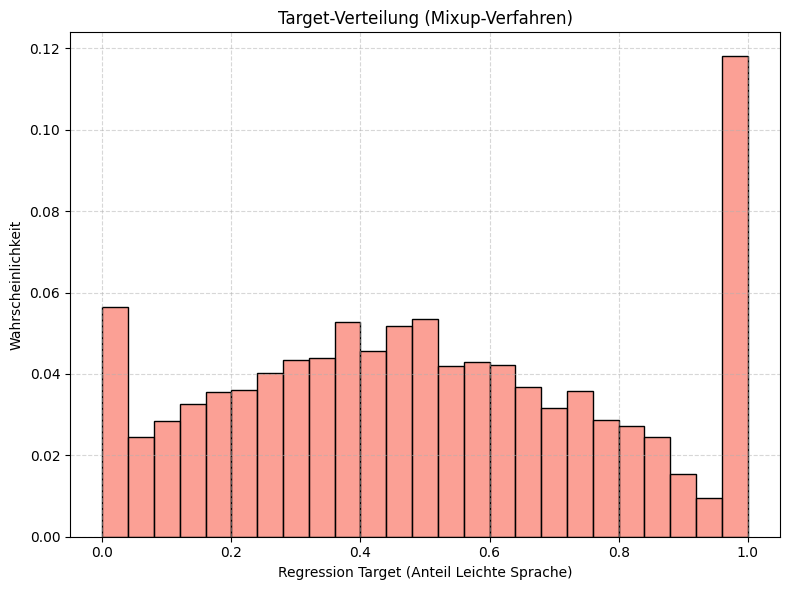

In [18]:
plt.figure(figsize=(8, 6))

sns.histplot(targets, bins=25, kde=False, color="salmon", stat="probability")
plt.title("Target-Verteilung (Mixup-Verfahren)")
plt.xlabel("Regression Target (Anteil Leichte Sprache)")
plt.ylabel("Wahrscheinlichkeit")
plt.xlim(-0.05, 1.05)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()